# 04 — Fine-tune YOLO

The "production" detector from the project brief: fine-tune a pretrained YOLO11n on the same 19 clean
scenes, using the same scene-level 5-fold split as notebook 03, so the comparison in notebook 06 is
apples-to-apples. This stage is intentionally framework-mediated (`ultralytics`) — notebook 03 already
made every mechanic (sliding window, IoU, NMS) explicit by hand, so here the goal is a strong, fast,
realistic result to honestly compare against that from-scratch baseline, not to re-derive YOLO's
internals.

This notebook feeds YOLO the whole scene shrunk to 640×640, which turns out to be a big handicap for an object
this small; notebook 05 re-does the experiment on native-resolution tiles.

To keep the comparison fair, we evaluate YOLO's predictions with the *same* `match_detections` /
`precision_recall` functions from `src/eval/metrics.py` that scored the sliding-window model — not
ultralytics' own mAP calculation, which uses a different matching procedure.

In [1]:
import ast
import shutil
import sys
import time
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import pandas as pd
import torch
from PIL import Image
from ultralytics import YOLO

from src.data.yolo_export import add_synthetic_training_images, export_yolo_fold
from src.eval.metrics import match_detections, mean_localization_error, precision_recall

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
RUNS_DIR = PROJECT_ROOT / "runs"
MODELS_DIR = PROJECT_ROOT / "models"
MODELS_DIR.mkdir(exist_ok=True)
plt.rcParams["figure.dpi"] = 110

YOLO_DEVICE = 0 if torch.cuda.is_available() else "cpu"
YOLO_BATCH = 32 if torch.cuda.is_available() else 16
print(f"YOLO device: {YOLO_DEVICE}, batch size: {YOLO_BATCH}")

scenes = pd.read_csv(PROCESSED_DIR / "clean_manifest.csv")
scenes["boxes"] = scenes["boxes"].apply(ast.literal_eval)
scenes["scene_id"] = scenes["scene_id"].astype(str)
fold_assignment = pd.read_csv(PROCESSED_DIR / "fold_assignment.csv")
fold_assignment["scene_id"] = fold_assignment["scene_id"].astype(str)
crop_pool = pd.read_csv(PROCESSED_DIR / "crop_pool.csv")
crop_pool["scene_id"] = crop_pool["scene_id"].astype(str)
N_FOLDS = fold_assignment["val_fold"].nunique()
IOU_THRESHOLD = 0.3
N_SYNTHETIC_PER_SCENE = 8  # 15 real train scenes -> 15 + 15*8 = 135 train images per fold


YOLO device: cpu, batch size: 16


## Export fold 0 to YOLO format, then add synthetic training scenes

`export_yolo_fold` (`src/data/yolo_export.py`) writes `train/{images,labels}` and `val/{images,labels}`
folders plus a `data.yaml`, converting our absolute-pixel `(x1,y1,x2,y2)` boxes to YOLO's normalized
`(class, cx, cy, w, h)` format — this part is unchanged from before.

New: `add_synthetic_training_images` then pastes real Waldo crops (from `crop_pool.csv`, built in
notebook 02) onto this fold's *training* scenes at new random positions, adding `N_SYNTHETIC_PER_SCENE`
extra training images per real one. Both the backgrounds and the crops are restricted to this fold's
training scenes only — `val/` is untouched, so evaluation stays on real, unmodified images.

*Correction:* an earlier run of this notebook pasted crops that were partly wrong — the crop pool was cut from
native scans using boxes that were misplaced for 8 of the 19 scenes (notebook 02, Part 2). The crop pool is now
built with orientation-corrected boxes and this notebook was retrained from scratch; the numbers below are from
that corrected run. (Training and scoring themselves use the Roboflow 640×640 images with Roboflow's own boxes,
which agree with each other, so they were never affected.)

In [2]:
fold0_dir = PROCESSED_DIR / "yolo_fold0"
data_yaml_fold0 = export_yolo_fold(scenes, fold_assignment, val_fold=0, out_dir=fold0_dir)

fold0_train_scenes = scenes.merge(fold_assignment, on="scene_id").query("val_fold != 0")
n_synth = add_synthetic_training_images(
    fold0_train_scenes, crop_pool, fold0_dir, n_per_scene=N_SYNTHETIC_PER_SCENE, seed=0
)
print(f"Added {n_synth} synthetic training images to {fold0_dir / 'train'}")

n_train = len(list((fold0_dir / "train" / "images").glob("*.jpg")))
n_val = len(list((fold0_dir / "val" / "images").glob("*.jpg")))
print(f"fold 0: {n_train} train images ({len(fold0_train_scenes)} real + {n_synth} synthetic), {n_val} val images (real only)")

sample_label = next((fold0_dir / "train" / "labels").glob("*.txt"))
print(f"\nExample label ({sample_label.name}): {sample_label.read_text()}")

Added 120 synthetic training images to D:\python_envs\wheres-wally\data\processed\yolo_fold0\train
fold 0: 135 train images (15 real + 120 synthetic), 4 val images (real only)

Example label (10.txt): 0 0.286719 0.119531 0.048438 0.089063
0 0.454688 0.179688 0.015625 0.043750


## Train fold 0 in detail

Starting from pretrained `yolo11n.pt` (nano — smallest YOLO11 variant) rather than training from random
weights: fine-tuning from COCO-pretrained weights lets the model reuse general-purpose visual features
and only adapt to "what Waldo looks like". `imgsz=640` matches our images' native resolution exactly.
Batch size is a little larger now (16, up from 8) since the training set is ~9x bigger with synthetic
images added; epochs/patience are similarly retuned for the new data volume rather than reused as-is.

In [3]:
fold0_weights = RUNS_DIR / "yolo_fold0" / "weights" / "best.pt"
if fold0_weights.exists():
    print(f"Reusing already-trained fold 0 weights at {fold0_weights} (resumed run)")
    model_fold0 = YOLO(str(fold0_weights))
else:
    model_fold0 = YOLO("yolo11n.pt")
    model_fold0.train(
        data=str(data_yaml_fold0),
        epochs=50,
        imgsz=640,
        batch=YOLO_BATCH,
        device=YOLO_DEVICE,
        patience=15,
        project=str(RUNS_DIR),
        name="yolo_fold0",
        exist_ok=True,
        verbose=False,
        plots=True,
    )

New https://pypi.org/project/ultralytics/8.4.155 available  Update with 'pip install -U ultralytics'


Ultralytics 8.4.154  Python-3.10.1 torch-2.14.0+cpu CPU (AMD Ryzen 3 4300U with Radeon Graphics)


engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=D:\python_envs\wheres-wally\data\processed\yolo_fold0\data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo_fold0, nbs=64, nms=None, opset=None, optimize=False, optimizer=auto, overlap_mask=True, pa

Overriding model.yaml nc=80 with nc=1



                   from  n    params  module                                       arguments                     


...

YOLO11n summary (fused): 100 layers, 2,582,347 parameters, 0 gradients, 6.4 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 1.6it/s 0.6s

                   all          4          4   0.000833       0.25   0.000379   0.000154


Speed: 1.7ms preprocess, 106.5ms inference, 0.0ms loss, 12.0ms postprocess per image


Results saved to D:\python_envs\wheres-wally\runs\yolo_fold0


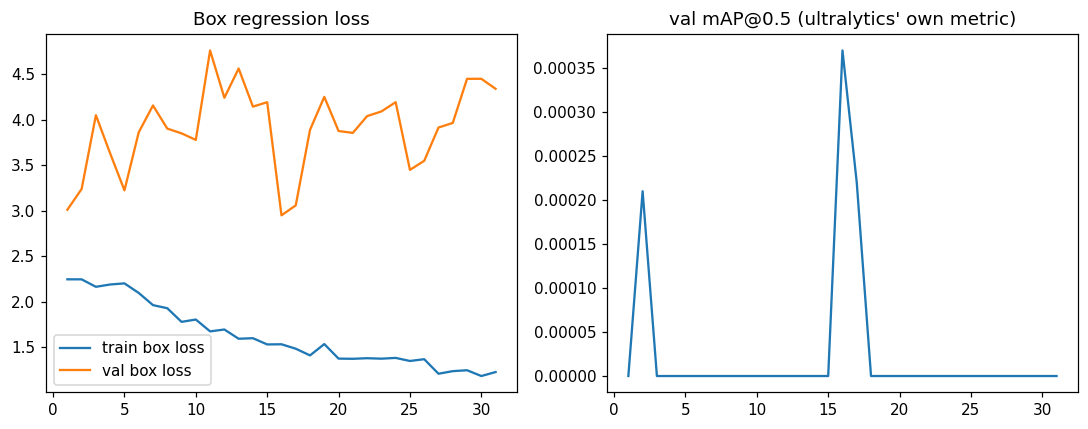

In [4]:
results_csv = RUNS_DIR / "yolo_fold0" / "results.csv"
results_df = pd.read_csv(results_csv)
results_df.columns = [c.strip() for c in results_df.columns]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(results_df["epoch"], results_df["train/box_loss"], label="train box loss")
axes[0].plot(results_df["epoch"], results_df["val/box_loss"], label="val box loss")
axes[0].legend()
axes[0].set_title("Box regression loss")
axes[1].plot(results_df["epoch"], results_df["metrics/mAP50(B)"])
axes[1].set_title("val mAP@0.5 (ultralytics' own metric)")
plt.tight_layout()
plt.show()

## Choosing an operating threshold

Same discipline as notebook 03: don't hardcode a confidence cutoff, sweep it on fold 0's held-out scenes.

**This sweep didn't find one.** Fold 0's model produced no true positive at *any* threshold — only false
positives (207 at 0.01 down to 1 at 0.20) and no detections at all from 0.30 up — so every F1 is 0 and there is
no "best" threshold. The code then falls back to a default of 0.1, and its printed line "Best F1 at
threshold=0.1" is misleading: 0.1 is that fallback, not a tuned value. **All five folds are therefore evaluated
at `conf=0.1`, an untuned operating point** — keep that in mind when reading the cross-validated numbers
below. (Fold 0 also happens to be one of the weakest folds — see the per-fold table further down — so a
sweep on it says little about the others.)

In [5]:
fold0_val_scenes = scenes.merge(fold_assignment, on="scene_id").query("val_fold == 0")

yolo_threshold_sweep = []
for thresh in [0.01, 0.02, 0.05, 0.1, 0.15, 0.2, 0.3, 0.4]:
    matches = []
    for _, scene in fold0_val_scenes.iterrows():
        image = Image.open(scene["image_path"])
        result = model_fold0.predict(image, conf=thresh, verbose=False)[0]
        pred_boxes = [tuple(b.xyxy[0].tolist()) for b in result.boxes]
        matches.append(match_detections(pred_boxes, scene["boxes"], iou_threshold=IOU_THRESHOLD))
    p, r = precision_recall(matches)
    f1 = 2 * p * r / (p + r) if (p + r) > 0 else 0.0
    tp = sum(m.true_positives for m in matches)
    fp = sum(m.false_positives for m in matches)
    yolo_threshold_sweep.append({"threshold": thresh, "precision": p, "recall": r, "f1": f1, "tp": tp, "fp": fp})

yolo_sweep_df = pd.DataFrame(yolo_threshold_sweep)
YOLO_CONF_THRESHOLD = float(yolo_sweep_df.loc[yolo_sweep_df["f1"].idxmax(), "threshold"]) if yolo_sweep_df["f1"].max() > 0 else 0.1
print(f"Best F1 at threshold={YOLO_CONF_THRESHOLD}")
yolo_sweep_df

Best F1 at threshold=0.1


,threshold,precision,recall,f1,tp,fp
0,0.01,0.0,0.0,0.0,0,207
1,0.02,0.0,0.0,0.0,0,82
2,0.05,0.0,0.0,0.0,0,26
3,0.10,0.0,0.0,0.0,0,9
4,0.15,0.0,0.0,0.0,0,4
5,0.20,0.0,0.0,0.0,0,1
6,0.30,0.0,0.0,0.0,0,0
7,0.40,0.0,0.0,0.0,0,0


In [6]:
yolo_sweep_df.to_csv(PROCESSED_DIR / "yolo_threshold_sweep.csv", index=False)
print(f"Saved YOLO threshold sweep to {PROCESSED_DIR / 'yolo_threshold_sweep.csv'}")

Saved YOLO threshold sweep to D:\python_envs\wheres-wally\data\processed\yolo_threshold_sweep.csv


**Per-fold training behaviour** (from `runs/yolo_fold{k}/results.csv`, ultralytics' own validation on each
fold's held-out scenes):

| fold | epochs run | best val mAP@0.5 | final train box loss | final val box loss |
|---|---|---|---|---|
| 0 | 31 (early stop) | 0.000 | 1.23 | 4.34 |
| 1 | 50 | 0.098 | 0.85 | 3.24 |
| 2 | 27 (early stop) | 0.252 | 1.40 | 2.49 |
| 3 | 31 (early stop) | 0.195 | 1.16 | 2.58 |
| 4 | 50 | 0.000 | 0.93 | 4.50 |

Two things stand out. First, in every fold the validation box loss is well above the training box loss
(between about 1.8× and 4.8×): the model fits its training scenes better than unseen ones, a clear
generalization gap. Second, quality varies enormously by fold — from 0 to 0.25 mAP — and with only 3–4
held-out scenes per fold, *which scenes* are held out matters more than any training detail. Fold 2 shows the
model can learn something transferable; folds 0 and 4 (best mAP 0.000) show it often doesn't.

## Qualitative check

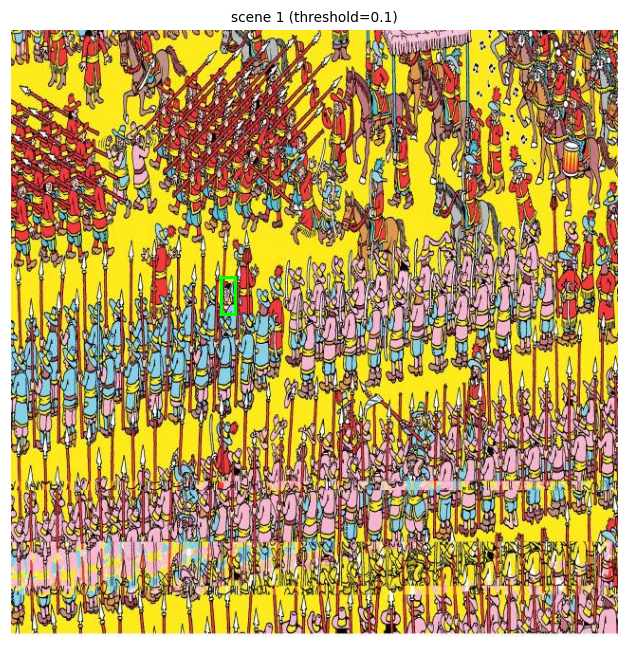

In [7]:
def show_yolo_detections(image, yolo_result, gt_boxes, title):
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(image)
    for box in gt_boxes:
        x1, y1, x2, y2 = box
        ax.add_patch(plt.Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, edgecolor="lime", linewidth=2))
    for box in yolo_result.boxes:
        x1, y1, x2, y2 = box.xyxy[0].tolist()
        ax.add_patch(plt.Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, edgecolor="red", linewidth=2))
        ax.text(x1, y1 - 4, f"{box.conf.item():.2f}", color="red", fontsize=8)
    ax.set_title(title, fontsize=9)
    ax.axis("off")
    plt.tight_layout()
    plt.show()


sample_scene = fold0_val_scenes.iloc[0]
sample_image = Image.open(sample_scene["image_path"])
result = model_fold0.predict(sample_image, conf=YOLO_CONF_THRESHOLD, verbose=False)[0]
show_yolo_detections(sample_image, result, sample_scene["boxes"], f"scene {sample_scene['scene_id']} (threshold={YOLO_CONF_THRESHOLD})")

## Full cross-validation (our own metrics, matching notebook 03)

Resumable: if a fold's `weights/best.pt` already exists on disk (e.g. from a run that got interrupted
partway through), reuse it instead of retraining — the synthetic data generation is seeded
deterministically per fold, so a fresh run would reproduce the same training set anyway.

In [8]:
yolo_all_matches = []
yolo_per_scene = []
yolo_fold_models = {0: model_fold0}

for fold in range(N_FOLDS):
    if fold == 0:
        fold_model = model_fold0
    else:
        weights_path = RUNS_DIR / f"yolo_fold{fold}" / "weights" / "best.pt"
        if weights_path.exists():
            print(f"fold {fold}: reusing already-trained weights (resumed run)")
            fold_model = YOLO(str(weights_path))
        else:
            fold_dir = PROCESSED_DIR / f"yolo_fold{fold}"
            data_yaml = export_yolo_fold(scenes, fold_assignment, val_fold=fold, out_dir=fold_dir)
            fold_train_scenes = scenes.merge(fold_assignment, on="scene_id").query("val_fold != @fold")
            add_synthetic_training_images(fold_train_scenes, crop_pool, fold_dir, n_per_scene=N_SYNTHETIC_PER_SCENE, seed=fold)

            fold_model = YOLO("yolo11n.pt")
            fold_model.train(
                data=str(data_yaml), epochs=50, imgsz=640, batch=YOLO_BATCH, device=YOLO_DEVICE, patience=15,
                project=str(RUNS_DIR), name=f"yolo_fold{fold}", exist_ok=True, verbose=False, plots=False,
            )
        yolo_fold_models[fold] = fold_model

    val_scenes = scenes.merge(fold_assignment, on="scene_id").query("val_fold == @fold")
    for _, scene in val_scenes.iterrows():
        image = Image.open(scene["image_path"])
        result = fold_model.predict(image, conf=YOLO_CONF_THRESHOLD, verbose=False)[0]
        pred_boxes = [tuple(b.xyxy[0].tolist()) for b in result.boxes]
        match = match_detections(pred_boxes, scene["boxes"], iou_threshold=IOU_THRESHOLD)
        yolo_all_matches.append(match)
        yolo_per_scene.append(
            {"scene_id": scene["scene_id"], "fold": fold, "tp": match.true_positives, "fp": match.false_positives, "fn": match.false_negatives}
        )
    print(f"fold {fold} done")

yolo_precision, yolo_recall = precision_recall(yolo_all_matches)
yolo_mle = mean_localization_error(yolo_all_matches)
print(f"\nYOLO across all {len(scenes)} scenes (IoU>={IOU_THRESHOLD}, conf_threshold={YOLO_CONF_THRESHOLD}):")
print(f"  Precision: {yolo_precision:.3f}")
print(f"  Recall:    {yolo_recall:.3f}")
print(f"  Mean localization error: {yolo_mle:.1f}px" if yolo_mle else "  No true positives")

pd.DataFrame(yolo_per_scene)

fold 0 done


New https://pypi.org/project/ultralytics/8.4.155 available  Update with 'pip install -U ultralytics'


Ultralytics 8.4.154  Python-3.10.1 torch-2.14.0+cpu CPU (AMD Ryzen 3 4300U with Radeon Graphics)


engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=D:\python_envs\wheres-wally\data\processed\yolo_fold1\data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo_fold1, nbs=64, nms=None, opset=None, optimize=False, optimizer=auto, overlap_mask=True, pa

Overriding model.yaml nc=80 with nc=1


...

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 2.0it/s 0.5s

                   all          3          2          0          0          0          0


Speed: 1.5ms preprocess, 150.7ms inference, 0.0ms loss, 1.7ms postprocess per image


fold 4 done

YOLO across all 19 scenes (IoU>=0.3, conf_threshold=0.1):
  Precision: 0.083
  Recall:    0.095
  Mean localization error: 2.3px


,scene_id,fold,tp,fp,fn
0,1,0,0,0,1
1,2,0,0,1,1
2,6,0,0,1,1
3,12,0,0,7,1
4,4,1,0,0,1
5,9,1,0,1,1
6,14,1,0,0,1
7,17,1,1,4,1
8,3,2,0,0,1
9,10,2,1,1,1


In [9]:
yolo_results_out = pd.DataFrame(yolo_per_scene)
yolo_results_out.to_csv(PROCESSED_DIR / "yolo_cv_results.csv", index=False)
print(f"Saved YOLO CV results to {PROCESSED_DIR / 'yolo_cv_results.csv'}")

Saved YOLO CV results to D:\python_envs\wheres-wally\data\processed\yolo_cv_results.csv


## Inference speed: sliding window vs. single forward pass

Notebook 03 flagged this as worth measuring directly: exhaustive multi-scale sliding-window inference
runs the classifier on thousands of crops per image, while YOLO does one forward pass over the whole
image at once.

In [10]:
n_runs = 3

start = time.perf_counter()
for _ in range(n_runs):
    model_fold0.predict(sample_image, conf=YOLO_CONF_THRESHOLD, verbose=False)
yolo_time = (time.perf_counter() - start) / n_runs
print(f"YOLO:            {yolo_time*1000:.0f} ms / image")

try:
    from src.models.sliding_window import detect
    from src.models.patch_classifier import PatchClassifier
    import torch

    sweep_path = PROCESSED_DIR / "sliding_window_threshold_sweep.csv"
    sw_threshold = pd.read_csv(sweep_path).pipe(lambda d: d.loc[d["f1"].idxmax(), "threshold"]) if sweep_path.exists() else 0.6

    sw_model = PatchClassifier()
    sw_model.load_state_dict(torch.load(MODELS_DIR / "sliding_window_classifier.pt", map_location="cpu"))

    start = time.perf_counter()
    for _ in range(n_runs):
        detect(sw_model, sample_image, score_threshold=sw_threshold)
    sw_time = (time.perf_counter() - start) / n_runs
    print(f"Sliding window:  {sw_time*1000:.0f} ms / image  ({sw_time/yolo_time:.0f}x slower than YOLO)")
except FileNotFoundError:
    print("Sliding-window model not found yet — run notebook 03 first.")

YOLO:            118 ms / image


Sliding window:  4328 ms / image  (37x slower than YOLO)


## Save the model

The saved detector is **the fold whose model scored best on its own held-out scenes** (ultralytics' val
mAP@0.5), not simply fold 0: fold 0's model has a best val mAP of 0.000 and detects nothing, so saving it
would give the demo (and notebook 05's visuals) a model that doesn't reflect the results above.

Two caveats. The winning fold's held-out numbers are optimistically biased, because it was picked
*because* it did best on them. And the model is trained on only 15 of the 19 scenes, so its detections on
those 15 are memorization, not evidence that it generalizes — only its 4 held-out scenes are.

In [11]:
best_map = {}
for k in range(N_FOLDS):
    fold_results = pd.read_csv(RUNS_DIR / f"yolo_fold{k}" / "results.csv")
    fold_results.columns = [c.strip() for c in fold_results.columns]
    best_map[k] = fold_results["metrics/mAP50(B)"].max()

best_fold = max(best_map, key=best_map.get)
print("best val mAP@0.5 per fold:", {k: round(v, 3) for k, v in best_map.items()})

shutil.copy(RUNS_DIR / f"yolo_fold{best_fold}" / "weights" / "best.pt", MODELS_DIR / "yolo_detector.pt")
print(f"Saved fold {best_fold}'s model to {MODELS_DIR / 'yolo_detector.pt'}")

best val mAP@0.5 per fold: {0: np.float64(0.0), 1: np.float64(0.098), 2: np.float64(0.252), 3: np.float64(0.195), 4: np.int64(0)}
Saved fold 2's model to D:\python_envs\wheres-wally\models\yolo_detector.pt


## Takeaways → what this motivates for notebook 05

- **Result (5-fold cross-validation, 15 real + 120 synthetic training images per fold, evaluated on real
  held-out scenes only, `conf=0.1`):** 2 of the 21 Waldo boxes found, 22 false positives, 19 missed —
  precision 0.083, recall 0.095, mean localization error 2.3 px (over just those 2 matches). Waldo is found in
  2 of the 18 scenes that contain him (10 and 17). Unlike the sliding-window model this is not a flood of false
  alarms (~1 per scene), but it misses about nine out of ten.
- **Run-to-run variation is as large as the effects we are trying to measure.** An earlier run of this same
  notebook found 4 boxes (34 false positives); this one, after the pasted crops were rebuilt with correct
  orientations (notebook 02, Part 2), found 2. A first pass without any synthetic data found none. With a 21-box
  evaluation set, 0, 2 and 4 hits are not reliably distinguishable, and this notebook has no ablation, so it
  cannot say whether copy-paste synthetic scenes help.
- **Treat the numbers as low-confidence.** Fold-to-fold results swing widely (table above), and `conf=0.1` is
  an untuned fallback (the fold-0 sweep found no true positive at any threshold).
- **Not a working detector.** The train/validation loss gap in every fold, and misses in 16 of the 18 scenes
  that contain Waldo, say the model largely fails to generalize from 15 real scenes to a new one.
- Inference is dozens of times faster than the sliding-window model — the timing cell above measures it
  fresh on every run (118 ms vs 4,328 ms per image, ~37×, in the latest run; earlier runs measured 32× and 49×).
- **A likely cause, followed up in notebook 05:** here the whole scene is shrunk to 640×640, which makes Waldo
  ~18×35 px (median) — about one cell of YOLO11n's coarsest feature map. Notebook 05 tests that directly by
  training and scanning on native-resolution tiles instead.

Notebook 06 puts all the models' cross-validated results side by side, looks at what each failure mode
actually looks like on real images, and writes up what would be worth trying next.